<a href="https://colab.research.google.com/github/akvdkharnath/My-Research/blob/master/Python%20Files/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem statment:**
need to develop a model to predicate a person is resuced or not ?  

**Libraries**

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statistics

In [57]:
df = pd.read_csv("https://raw.githubusercontent.com/akvdkharnath/My-Research/master/Python%20Files/Data/titanic_data_set.csv")

In [20]:
df.head()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
df.isnull() 

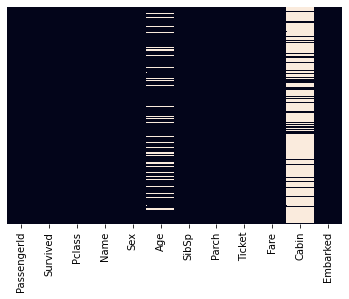

In [70]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)

yticklabels=False --> remove y axis scale

cbar= false --> remove index colour from 0 to 1

from this we can say there is lot of data missing in cabin column and some data missing in age column

**Data Analysis**:

Survived report:

1. most of then not survived
2. survived rate of women is more grater than men
3. survived rate of p-class 1st >>> 2ed > 3rd  
4. survived rate of age unable to identify 
5. age split is in standard deviation 

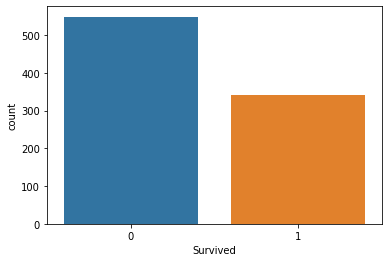

In [60]:
sns.countplot(x = 'Survived',data = df)

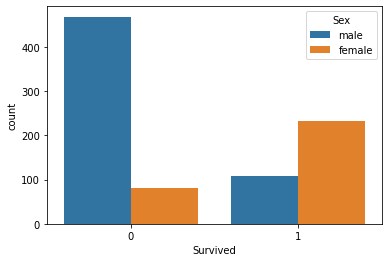

In [23]:
sns.countplot(x = 'Survived',data = df,hue='Sex')

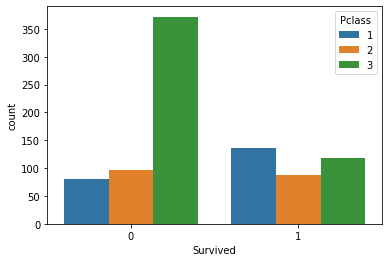

In [24]:
sns.countplot(x = 'Survived',data = df,hue='Pclass')

In [ ]:
sns.countplot(x = 'Survived',data = df,hue='Age')

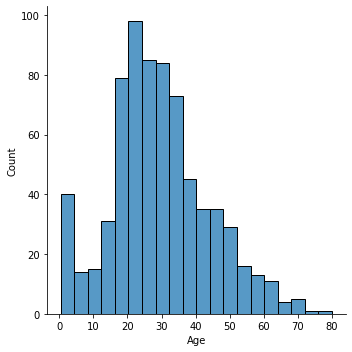

In [27]:
sns.displot(df["Age"].dropna(),kde = False)

**Data Cleaning**

for Age column 
first find mean , median , mode for the availability data after fillling missing data also we need to get almost same values 

AxesSubplot(0.125,0.125;0.775x0.755)
float64
int64
Mean: 29.679271708683473
Median: 28.0
Mode: 24


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


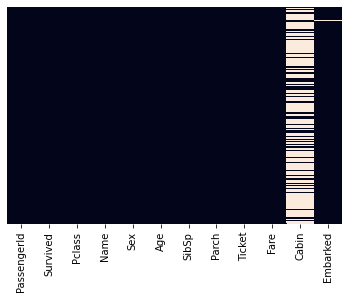

In [69]:
df1 = df.dropna(subset = ['Age'])
print(sns.heatmap(df1.isnull(),yticklabels=False,cbar=False))
print(df1['Age'].dtype)
df1['Age'] = df1['Age'].astype(int)
print(df1['Age'].dtype)

print("Mean:",statistics.mean(list(df1['Age']))) # 29.6
print("Median:",statistics.median(list(df1['Age']))) # 28
print("Mode:",statistics.mode(list(df1['Age']))) # 24


**attempt -1 (Sex Vs Age)**

from box plot:
1. male median --> 30
2. female median --> 27

with this data i can fill age as 30 if sex is male else age as 27 if sex is female 


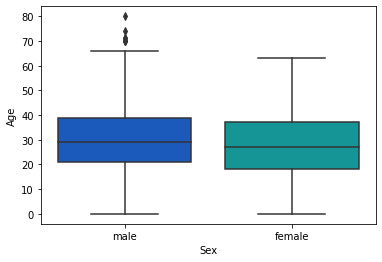

In [61]:
sns.boxplot(x = 'Sex',y = 'Age',data = df1,palette='winter')

In [65]:
df_sex = df.copy()
df_sex

print(df_sex["Age"])

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64


AxesSubplot(0.125,0.125;0.775x0.755)
Mean: 29.58043771043771
Median: 30.0
Mode: 30.0


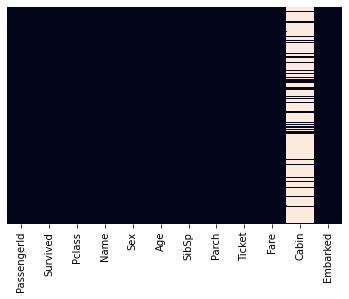

In [68]:
def age_cal_1(col):
  age = col[0]
  sex = col[1]
  if pd.isnull(age):
    if sex == 'male':
      return 30
    else:
      return 27
  else:
    return age


df_sex['Age'] = df_sex[["Age","Sex"]].apply(age_cal_1,axis = 1)
print(sns.heatmap(df_sex.isnull(),yticklabels=False,cbar=False))
print("Mean:",statistics.mean(list(df_sex['Age']))) # 29.5
print("Median:",statistics.median(list(df_sex['Age']))) # 30
print("Mode:",statistics.mode(list(df_sex['Age']))) # 30

**attempt -2 (Pclass Vs Age)**

from box plot:
1. 1st class median --> 38
2. 2ed class median --> 32
3. 3rd class median --> 27

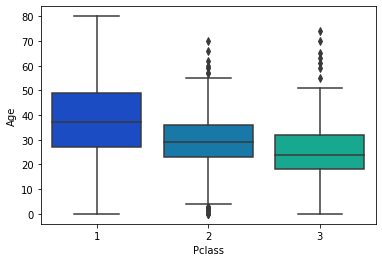

In [67]:
sns.boxplot(x = 'Pclass',y = 'Age',data = df1,palette='winter')

AxesSubplot(0.125,0.125;0.775x0.755)
Mean: 29.16292929292929
Median: 27.0
Mode: 27.0


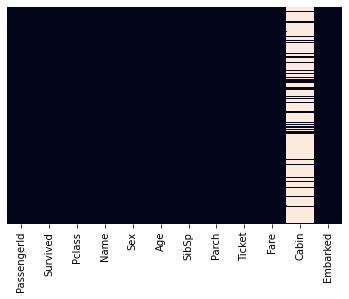

In [72]:
df_pclass = df.copy()

def age_cal_2(col):
  age = col[0]
  pclass = col[1]
  if pd.isnull(age):
    if pclass == 1:
      return 38
    elif pclass == 2:
      return 32
    else:
      return 27
  else:
    return age

df_pclass['Age'] = df_pclass[["Age","Pclass"]].apply(age_cal_1,axis = 1)
print(sns.heatmap(df_pclass.isnull(),yticklabels=False,cbar=False))
print("Mean:",statistics.mean(list(df_pclass['Age']))) # 29.1
print("Median:",statistics.median(list(df_pclass['Age']))) # 27
print("Mode:",statistics.mode(list(df_pclass['Age']))) # 27

**Comperision:**

| Data   | Mean | Median | Mode |
|--------|------|--------|------|   
|Original|29.6  | 28     | 24      |
|approch1|29.5  | 30     | 30      |
|approch2|29.1  | 27     | 27      |

approch 2 is almost mattching so we will go with that 

